In [ ]:
# CREDIT CARD FRAUDELENT

In [1]:
# Setup R

install.packages("tidyverse")
install.packages("ggplot2")
install.packages("corrplot")
install.packages("lubridate")

library(tidyverse)
library(ggplot2)
library(corrplot)
library(lubridate)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘timechange’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded



In [3]:
# Upload Dataset

data <- read.csv("fraudTest.csv")

head(data)
str(data)
summary(data)

,X,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,⋯,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>
1,0,2020-06-21 12:14:25,2.291164e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,⋯,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.98639,-81.20071,0
2,1,2020-06-21 12:14:33,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,⋯,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.45050,-109.96043,0
3,2,2020-06-21 12:14:53,3.598215e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,⋯,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.49581,-74.19611,0
4,3,2020-06-21 12:15:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,⋯,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.81240,-80.88306,0
5,4,2020-06-21 12:15:17,3.526826e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,⋯,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.95915,-85.88473,0
6,5,2020-06-21 12:15:37,3.040768e+13,fraud_Daugherty LLC,kids_pets,19.55,Danielle,Evans,F,76752 David Lodge Apt. 064,⋯,42.1939,-76.7361,520,Psychotherapist,1991-10-13,798db04aaceb4febd084f1a7c404da93,1371816937,41.74716,-77.58420,0


'data.frame':	124327 obs. of  23 variables:
 $ X                    : int  0 1 2 3 4 5 6 7 8 9 ...
 $ trans_date_trans_time: chr  "2020-06-21 12:14:25" "2020-06-21 12:14:33" "2020-06-21 12:14:53" "2020-06-21 12:15:15" ...
 $ cc_num               : num  2.29e+15 3.57e+15 3.60e+15 3.59e+15 3.53e+15 ...
 $ merchant             : chr  "fraud_Kirlin and Sons" "fraud_Sporer-Keebler" "fraud_Swaniawski, Nitzsche and Welch" "fraud_Haley Group" ...
 $ category             : chr  "personal_care" "personal_care" "health_fitness" "misc_pos" ...
 $ amt                  : num  2.86 29.84 41.28 60.05 3.19 ...
 $ first                : chr  "Jeff" "Joanne" "Ashley" "Brian" ...
 $ last                 : chr  "Elliott" "Williams" "Lopez" "Williams" ...
 $ gender               : chr  "M" "F" "F" "M" ...
 $ street               : chr  "351 Darlene Green" "3638 Marsh Union" "9333 Valentine Point" "32941 Krystal Mill Apt. 552" ...
 $ city                 : chr  "Columbia" "Altonah" "Bellmore" "Titusville" ..

       X          trans_date_trans_time     cc_num            merchant        
 Min.   :     0   Length:124327         Min.   :6.042e+10   Length:124327     
 1st Qu.: 31082   Class :character      1st Qu.:1.800e+14   Class :character  
 Median : 62163   Mode  :character      Median :3.520e+15   Mode  :character  
 Mean   : 62163                         Mean   :4.159e+17                     
 3rd Qu.: 93244                         3rd Qu.:4.635e+15                     
 Max.   :124326                         Max.   :4.992e+18                     
                                                                              
   category              amt              first               last          
 Length:124327      Min.   :    1.00   Length:124327      Length:124327     
 Class :character   1st Qu.:    9.63   Class :character   Class :character  
 Mode  :character   Median :   47.34   Mode  :character   Mode  :character  
                    Mean   :   69.34                        

In [21]:
# Step 1: Check the Column Type

str(data$is_fraud)

 int [1:124327] 0 0 0 0 0 0 0 0 0 0 ...


In [33]:
# Step 2: Converting is_fraud to Numeric

data$is_fraud <- as.numeric(as.character(data$is_fraud))
str(data$is_fraud)

 num [1:124327] 0 0 0 0 0 0 0 0 0 0 ...


In [34]:
# Step 3: Handle Missing Values

fraud_transactions <- sum(data$is_fraud, na.rm = TRUE)

In [35]:
# Step 4: Calculate Statistics

total_transactions <- nrow(data)

fraud_transactions <- sum(data$is_fraud, na.rm = TRUE)

fraud_rate <- fraud_transactions / total_transactions

print(total_transactions)
print(fraud_transactions)
print(fraud_rate)

[1] 124327
[1] 493
[1] 0.003965349


In [36]:
# Step 5: Show Fraud Distribution

table(data$is_fraud)


     0      1 
123833    493 

In [37]:
# Step 6: Fraud Percentage

prop.table(table(data$is_fraud))


          0           1 
0.996034619 0.003965381 

In [5]:
# Convert unix_time to Date

data$transaction_time <- as.POSIXct(data$unix_time, origin="1970-01-01")

data$hour <- hour(data$transaction_time)

data$day <- wday(data$transaction_time, label=TRUE)

data$month <- month(data$transaction_time, label=TRUE)

In [6]:
head(data[,c("transaction_time","hour","day","month")])

,transaction_time,hour,day,month
,<dttm>,<int>,<ord>,<ord>
1,2013-06-21 12:14:25,12,Fri,Jun
2,2013-06-21 12:14:33,12,Fri,Jun
3,2013-06-21 12:14:53,12,Fri,Jun
4,2013-06-21 12:15:15,12,Fri,Jun
5,2013-06-21 12:15:17,12,Fri,Jun
6,2013-06-21 12:15:37,12,Fri,Jun


In [38]:
# Create Customer Age

data$dob <- as.Date(data$dob)

data$age <- as.numeric(difftime(Sys.Date(), data$dob, units="weeks"))/52

summary(data$age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  21.19   39.02   50.45   52.52   63.67  101.71       1 

In [39]:
# Create Distance Variable

data$distance <- sqrt((data$lat - data$merch_lat)^2 +
                      (data$long - data$merch_long)^2)

summary(data$distance)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
0.004848 0.564821 0.797201 0.765002 0.976510 1.411574        1 

In [40]:
# Descriptive Statistics

summary(data$amt)

mean(data$amt)

sd(data$amt)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     9.63    47.34    69.34    82.92 13149.15 

[1] 69.33961

[1] 153.0756

In [41]:
# Fraud Distribution Plot

data %>%
group_by(is_fraud) %>%
summarise(
mean_amount = mean(amt),
median_amount = median(amt),
sd_amount = sd(amt)
)

is_fraud,mean_amount,median_amount,sd_amount
<dbl>,<dbl>,<dbl>,<dbl>
0,67.56425,47.18,148.7570
1,515.37221,348.61,389.1823
NA,22.94000,22.94,NA


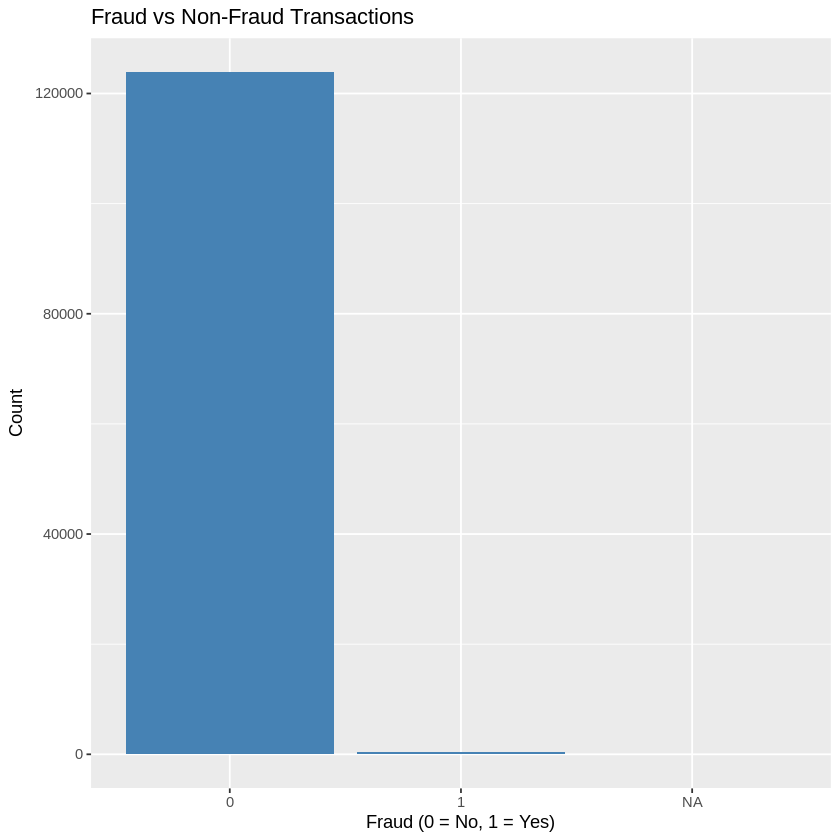

In [42]:
# Transaction Amount vs Fraud

ggplot(data, aes(x=factor(is_fraud))) +
geom_bar(fill="steelblue") +
labs(title="Fraud vs Non-Fraud Transactions",
x="Fraud (0 = No, 1 = Yes)",
y="Count")

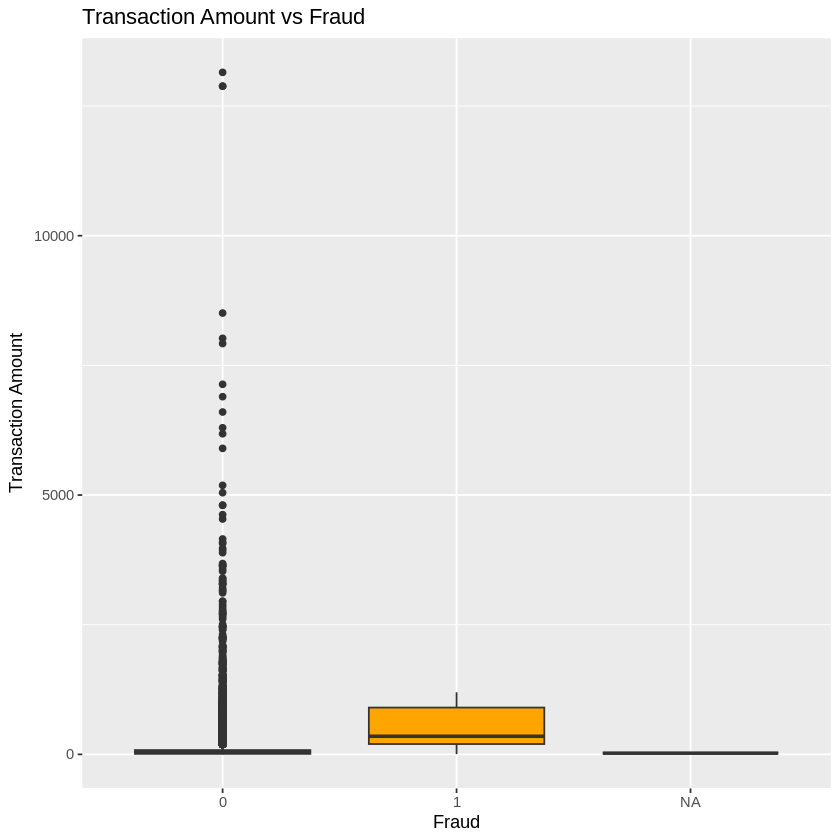

In [43]:
# Fraud by Category

ggplot(data, aes(x=factor(is_fraud), y=amt)) +
geom_boxplot(fill="orange") +
labs(title="Transaction Amount vs Fraud",
x="Fraud",
y="Transaction Amount")

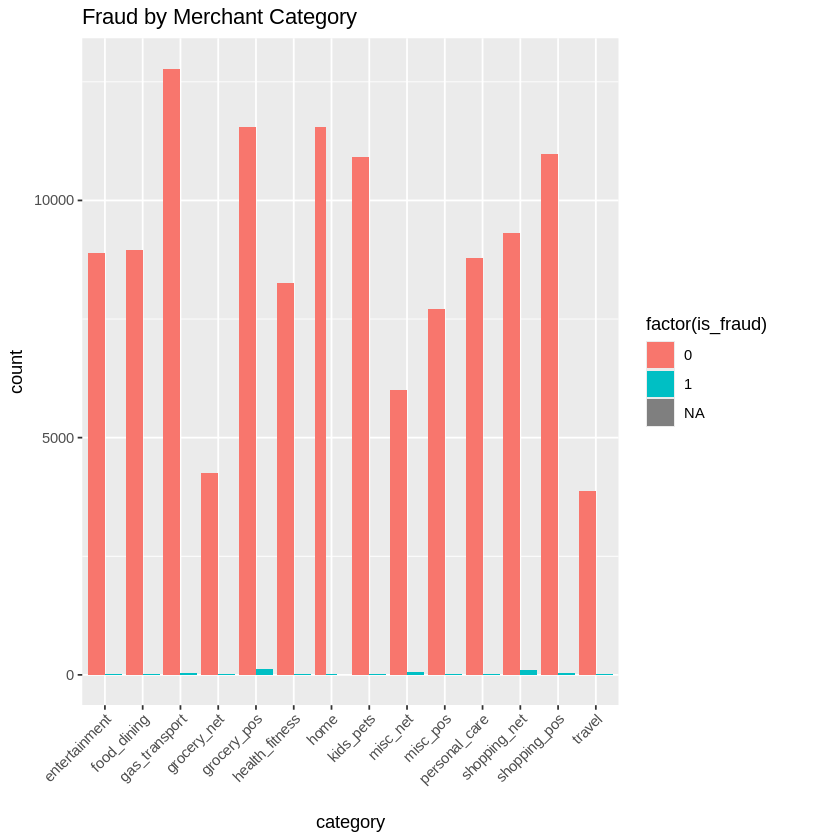

In [44]:
# Fraud by Hour

ggplot(data, aes(x=category, fill=factor(is_fraud))) +
geom_bar(position="dodge") +
theme(axis.text.x = element_text(angle=45, hjust=1)) +
labs(title="Fraud by Merchant Category")

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_count()`).”


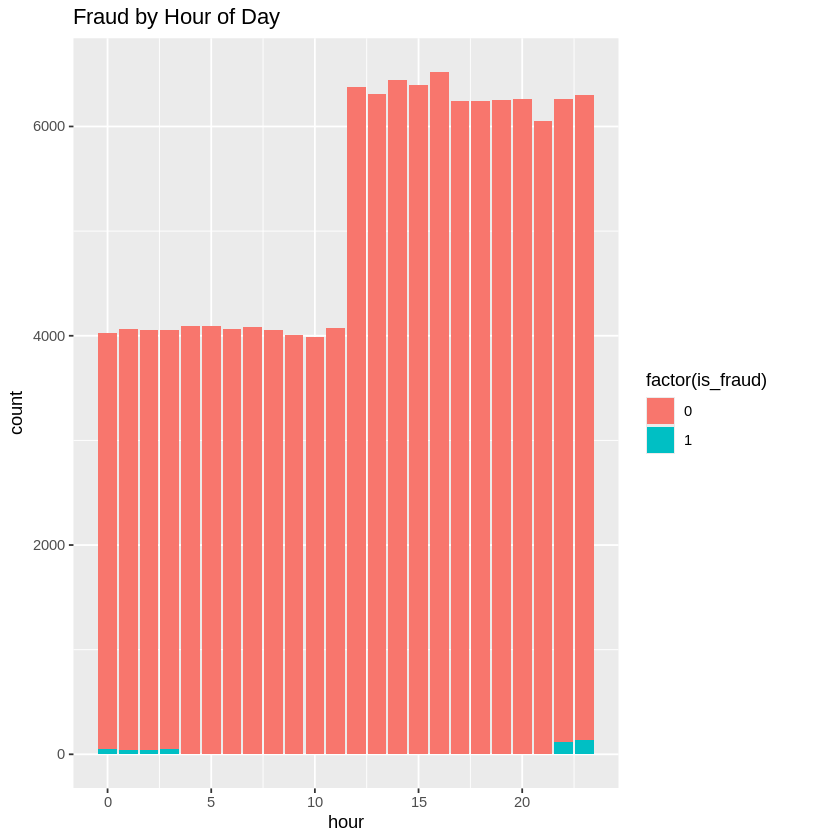

In [45]:
# Correlation Matrix

ggplot(data, aes(x=hour, fill=factor(is_fraud))) +
geom_bar() +
labs(title="Fraud by Hour of Day")

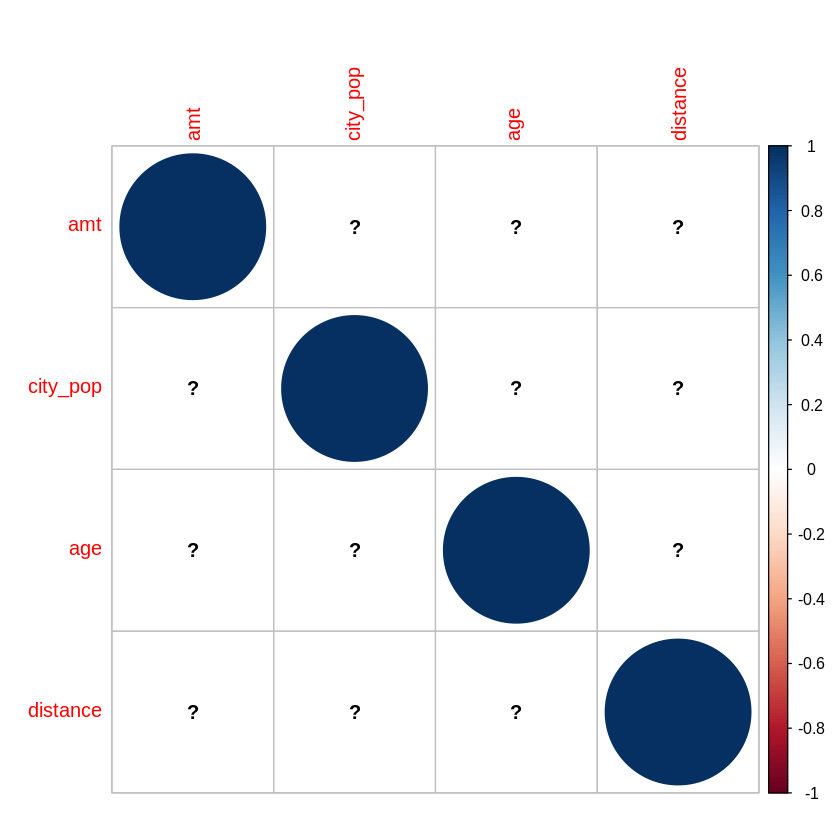

In [46]:
# Correlation Matrix

numeric_data <- data[,c("amt","city_pop","age","distance")]

cor_matrix <- cor(numeric_data)

corrplot(cor_matrix, method="circle")

In [48]:
# Normality Test

sample_amt <- sample(data$amt,5000)

shapiro.test(sample_amt)


	Shapiro-Wilk normality test

data:  sample_amt
W = 0.4553, p-value < 2.2e-16


In [49]:
# T-Test
# H0: Fraud and non-fraud transactions have same mean amount.

t.test(amt ~ is_fraud, data=data)


	Welch Two Sample t-test

data:  amt by is_fraud
t = -25.541, df = 492.57, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -482.2566 -413.3593
sample estimates:
mean in group 0 mean in group 1 
       67.56425       515.37221 


In [50]:
# Chi-Square Test
# Fraud vs Category.

table_category <- table(data$category,data$is_fraud)

chisq.test(table_category)


	Pearson's Chi-squared test

data:  table_category
X-squared = 402.26, df = 13, p-value < 2.2e-16


In [51]:
# Regression Model

model <- lm(is_fraud ~ amt + age + city_pop + distance + hour, data=data)

summary(model)


Call:
lm(formula = is_fraud ~ amt + age + city_pop + distance + hour, 
    data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.99535 -0.00498 -0.00214  0.00000  1.00334 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -4.698e-03  8.576e-04  -5.478 4.31e-08 ***
amt          7.578e-05  1.145e-06  66.174  < 2e-16 ***
age          3.798e-05  1.019e-05   3.725 0.000195 ***
city_pop    -1.125e-09  5.820e-10  -1.933 0.053196 .  
distance    -6.527e-04  6.157e-04  -1.060 0.289129    
hour         1.576e-04  2.625e-05   6.002 1.95e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.06176 on 124320 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.03418,	Adjusted R-squared:  0.03415 
F-statistic:   880 on 5 and 124320 DF,  p-value: < 2.2e-16


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


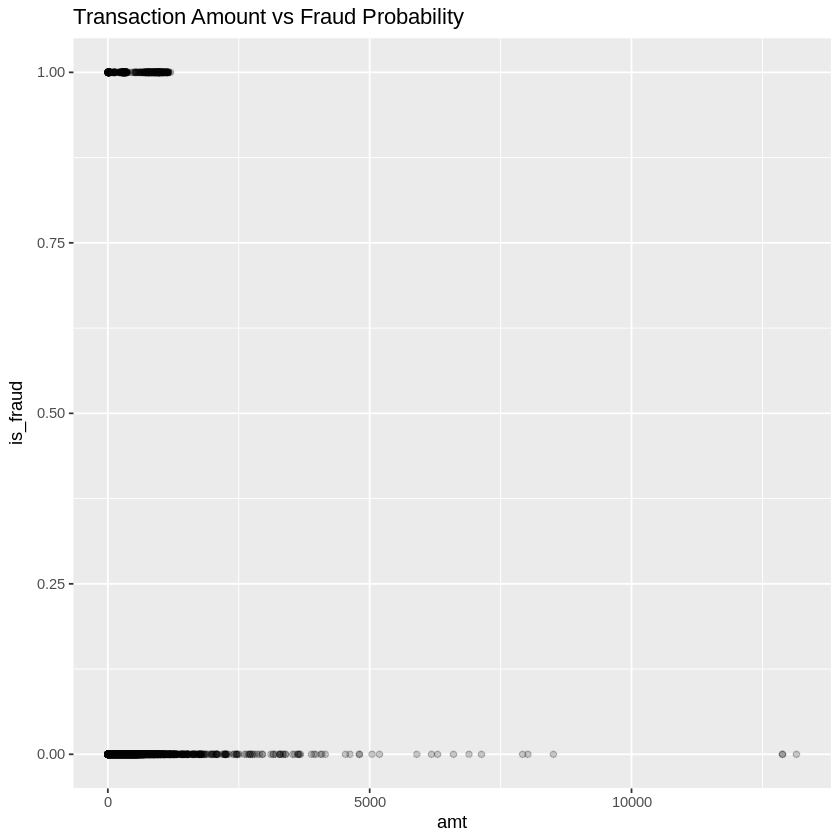

In [52]:
# Scatter Plot

ggplot(data, aes(x=amt,y=is_fraud)) +
geom_point(alpha=0.2) +
labs(title="Transaction Amount vs Fraud Probability")